In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import spikeinterface.full as si
import hypo_sleep
from hypo_sleep import Session, PipelineManager

In [2]:
data_path = Path("/gpfs01/born/animal/DanielG/hypo_sleep/processed_data/")
animal = "HYDO03"
date = "2025-02-18_09-19-26"
config_id = "b7bf"

In [3]:
session = Session(data_path, animal, date, config_id)

In [4]:
%reload_ext autoreload
%autoreload 2

In [5]:
session.config["analysis"][-1]["parameters"]["save"] = False

In [6]:
results = hypo_sleep.so_detection.run(
    session, **session.config["analysis"][-1]["parameters"]
)

Processing channel 39
Processing channel 45


ValueError: Cannot mask with non-boolean array containing NA / NaN values

In [ ]:
debug

> /gpfs01/born/user/dgramling/miniforge3/envs/hypo-sleep-no-si/lib/python3.12/site-packages/pandas/core/common.py(136)is_bool_indexer()
    134                     # Don't raise on e.g. ["A", "B", np.nan], see
    135                     #  test_loc_getitem_list_of_labels_categoricalindex_with_na
--> 136                     raise ValueError(na_msg)
    137                 return False
    138             return True

> /gpfs01/born/user/dgramling/miniforge3/envs/hypo-sleep-no-si/lib/python3.12/site-packages/pandas/core/frame.py(4092)__getitem__()
   4090 
   4091         # Do we have a (boolean) 1d indexer?
-> 4092         if com.is_bool_indexer(key):
   4093             return self._getitem_bool_array(key)
   4094 

> /gpfs01/born/user/dgramling/src/Hypothalamic_Sleep/src/hypo_sleep/pipelines/so_detection.py(180)process_zero_crosses()
    178             event_df.loc[event_df["channel"] == ch, "valid"] = True
    179 
--> 180     event_df = event_df[event_df["valid"]]
    181 
    182

In [ ]:
results["df"]

down_crossing  up_crossing  end_crossing  \
channel event_number                                             
39      8                   409.264      409.508       409.928   
        9                   409.928      409.996       410.772   
        10                  410.772      410.876       411.380   
        20                  415.940      416.124       416.988   
        29                  421.412      421.536       422.368   
...                             ...          ...           ...   
45      19014             19967.268    19967.464     19967.800   
        19018             19969.692    19969.816     19970.272   
        19020             19971.280    19971.536     19971.904   
        19025             19973.428    19973.684     19974.120   
        19026             19974.120    19974.388     19975.060   

                      down_state_dur  total_dur  neg_peak_val neg_peak_idx  \
channel event_number                                                         
39      8                      0.244      0.664    -70.680870     [102345]   
        9                      0.068      0.844    -59.968876     [102505]   
        10                     0.104      0.608    -38.544880     [102709]   
        20                     0.184      1.048    -49.012730     [104005]   
        29                     0.124      0.956      9.918516     [105353]   
...                              ...        ...           ...          ...   
45      19014                  0.196      0.532   -363.719604    [4991842]   
        19018                  0.124      0.580   -122.013008    [4992440]   
        19020                  0.256      0.624   -675.466187    [4992851]   
        19025                  0.256      0.692   -297.128235    [4993393]   
        19026                  0.268      0.940   -517.105652    [4993562]   

                      pos_peak_val  peak_to_peak  valid waveform_onset_time  \
channel event_number                                                          
39      8                37.446213    108.127083   True            [406.88]   
        9                 2.990814     62.959690   True            [407.52]   
        10               21.088291     59.633171   True           [408.336]   
        20               92.959389    141.972122   True            [413.52]   
        29              146.824554    156.743073   True           [418.912]   
...                            ...           ...    ...                 ...   
45      19014            75.777466    439.497070   True         [19964.868]   
        19018           110.690643    232.703644   True          [19967.26]   
        19020            22.980438    698.446655   True         [19968.904]   
        19025            61.922058    359.050293   True         [19971.072]   
        19026            27.344585    544.450256   True         [19971.748]   

                                                          SOGA_waveform  \
channel event_number                                                      
39      8             [19.714958, 23.133032, 26.490068, 29.816586, 3...   
        9             [-22.309032, -19.348736, -16.418959, -13.5197,...   
        10            [-65.03495, -72.90872, -80.47732, -87.67968, -...   
        20            [-21.11881, -24.079105, -26.978365, -29.786068...   
        29            [38.48384, 35.767696, 33.02103, 30.243845, 27....   
...                                                                 ...   
45      19014         [28.90103, 30.213326, 31.55614, 32.868435, 34....   
        19018         [-122.19612, -132.51138, -142.88766, -153.2639...   
        19020         [29.206215, 33.326214, 37.47673, 41.718803, 45...   
        19025         [28.260141, 31.189919, 34.089176, 36.988434, 3...   
        19026         [48.40236, 46.35762, 44.22132, 41.993473, 39.7...   

                                                     SOGAPhase_waveform  
channel event_number                                                  

In [ ]:
results["df"].loc["39"]

,down_crossing,up_crossing,end_crossing,down_state_dur,total_dur,neg_peak_val,neg_peak_idx,pos_peak_val,peak_to_peak,valid,waveform_onset_time,SOGA_waveform,SOGAPhase_waveform
event_number,,,,,,,,,,,,,
8,409.264,409.508,409.928,0.244,0.664,-70.680870,[102345],37.446213,108.127083,True,[406.88],"[19.714958, 23.133032, 26.490068, 29.816586, 3...","[-5.676443, -5.371258, -5.005036, -4.6082954, ..."
9,409.928,409.996,410.772,0.068,0.844,-59.968876,[102505],2.990814,62.959690,True,[407.52],"[-22.309032, -19.348736, -16.418959, -13.5197,...","[4.455703, 4.455703, 4.3946657, 4.30311, 4.150..."
10,410.772,410.876,411.380,0.104,0.608,-38.544880,[102709],21.088291,59.633171,True,[408.336],"[-65.03495, -72.90872, -80.47732, -87.67968, -...","[7.110813, 6.2562947, 5.371258, 4.3946657, 3.4..."
20,415.940,416.124,416.988,0.184,1.048,-49.012730,[104005],92.959389,141.972122,True,[413.52],"[-21.11881, -24.079105, -26.978365, -29.786068...","[-0.91555536, -1.129185, -1.3428144, -1.525925..."
29,421.412,421.536,422.368,0.124,0.956,9.918516,[105353],146.824554,156.743073,True,[418.912],"[38.48384, 35.767696, 33.02103, 30.243845, 27....","[-5.9816284, -5.676443, -5.3407393, -4.943999,..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
18715,19970.336,19970.588,19971.260,0.252,0.924,-160.924103,[4992612],29.602957,190.527054,True,[19967.948],"[-12.756738, -13.550219, -14.282663, -15.01510...","[-1.4648886, -1.2207404, -0.94607383, -0.64088..."
18716,19971.260,19971.536,19971.860,0.276,0.600,-307.535034,[4992850],106.784271,414.319305,True,[19968.9],"[6.8361464, 8.728294, 10.6814785, 12.726219, 1...","[0.061037023, -0.6714072, -1.4038515, -2.13629..."
18721,19973.408,19973.676,19974.104,0.268,0.696,-116.122932,[4993392],61.677910,177.800842,True,[19971.068],"[38.026066, 37.171547, 36.317028, 35.46251, 34...","[3.051851, 1.7395551, 0.42725915, -0.91555536,..."


In [17]:
rng = np.random.default_rng()
random_indices = rng.choice(
    results["df"].loc["39"].index.to_numpy(),
    size=10,
    replace=False,
)

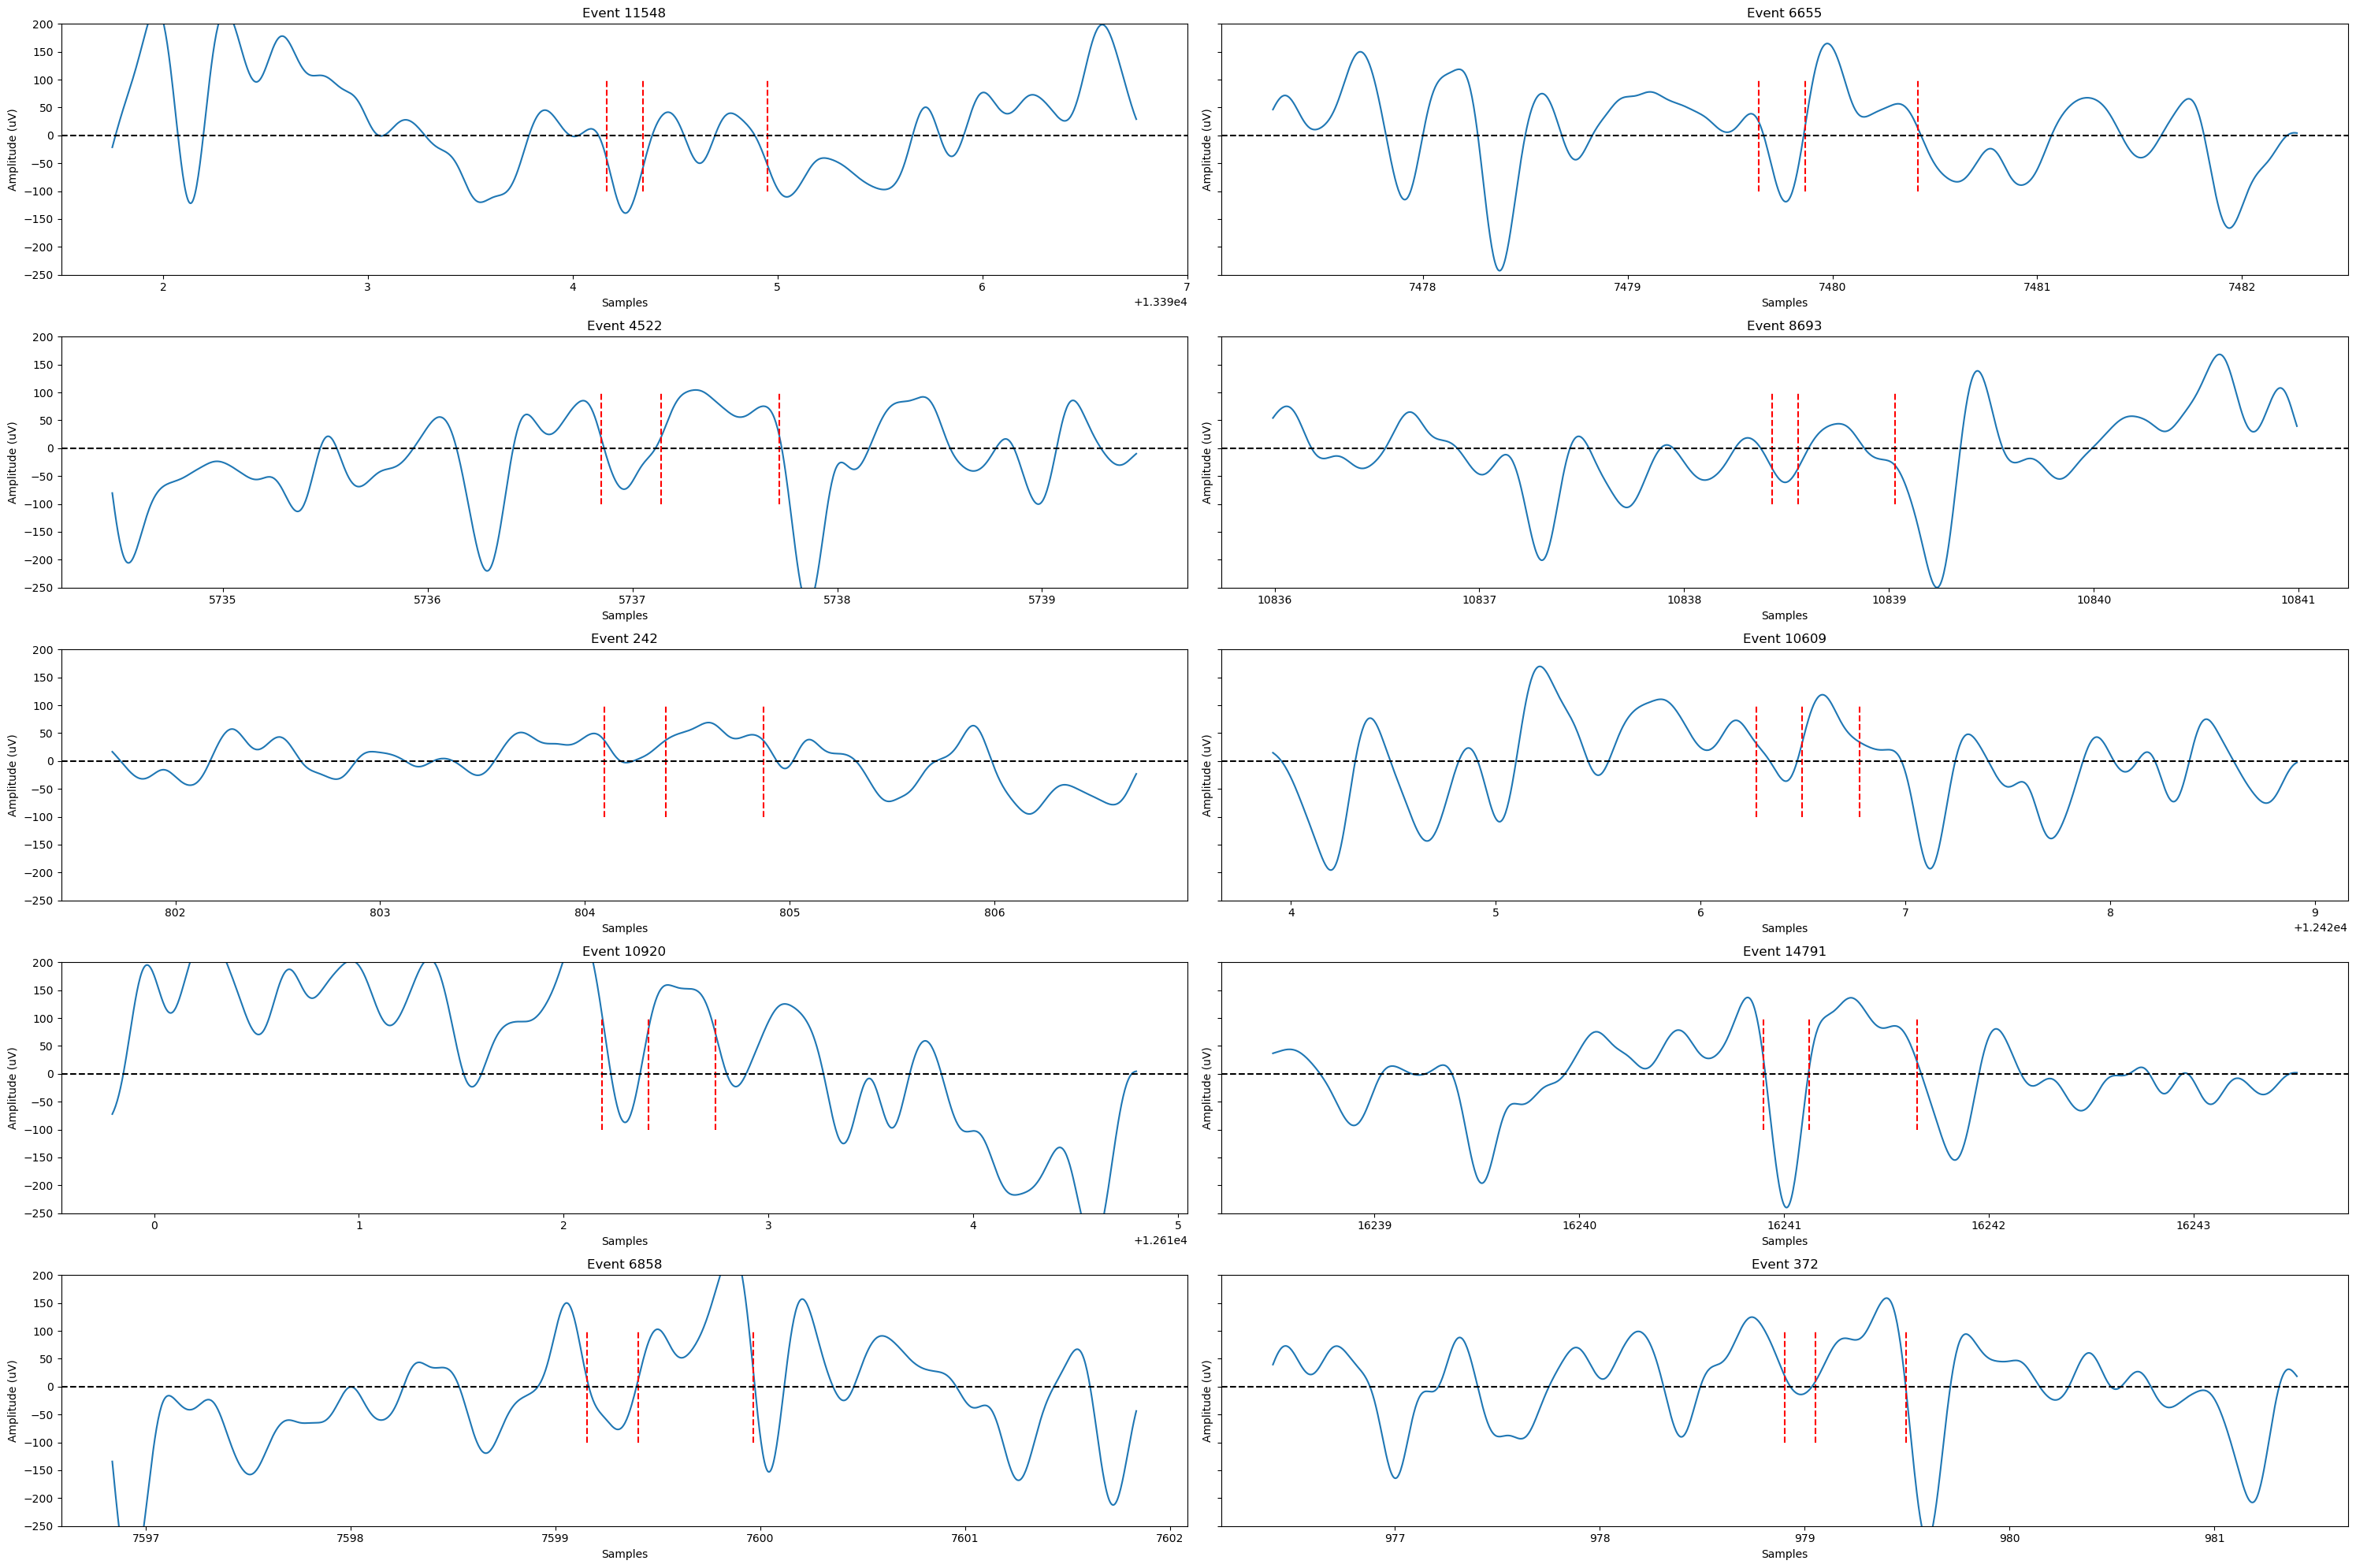

In [20]:
import matplotlib.pyplot as plt

times = results["rec_times"]
fig, axs = plt.subplots(nrows=5, ncols=2, figsize=(30, 20), sharey=True)
for event_ind, ax in zip(random_indices, axs.flatten()):
    event_ind
    window_start_time = results["df"].loc["39"].loc[event_ind, "waveform_onset_time"]
    time_ind = np.searchsorted(times, window_start_time)[0]
    waveform = results["df"].loc["39"].loc[event_ind, "SOGA_waveform"]
    x_time = times[time_ind : time_ind + waveform.size]
    ax.plot(x_time, waveform)
    crossings = (
        results["df"]
        .loc["39"]
        .loc[event_ind, ["down_crossing", "up_crossing", "end_crossing"]]
    )
    ax.vlines(
        x=crossings,
        ymin=-100,
        ymax=100,
        color="r",
        linestyle="--",
    )
    ax.set_title(f"Event {event_ind}")
    ax.set_xlabel("Samples")
    ax.set_ylabel("Amplitude (uV)")
    # ax.set_xlim(0, sample_window)
    ax.set_ylim(-250, 200)
    ax.axhline(0, color="k", linestyle="--")
fig.tight_layout()
# fig.savefig(
#     Path(session.config.get("output_path"), "so_detection_test_03.png"),
#     dpi=400,
#     facecolor="w",
#     bbox_inches="tight",
#     transparent=False,
# )

In [14]:
np.arange(-100, -1)

array([-100,  -99,  -98,  -97,  -96,  -95,  -94,  -93,  -92,  -91,  -90,
        -89,  -88,  -87,  -86,  -85,  -84,  -83,  -82,  -81,  -80,  -79,
        -78,  -77,  -76,  -75,  -74,  -73,  -72,  -71,  -70,  -69,  -68,
        -67,  -66,  -65,  -64,  -63,  -62,  -61,  -60,  -59,  -58,  -57,
        -56,  -55,  -54,  -53,  -52,  -51,  -50,  -49,  -48,  -47,  -46,
        -45,  -44,  -43,  -42,  -41,  -40,  -39,  -38,  -37,  -36,  -35,
        -34,  -33,  -32,  -31,  -30,  -29,  -28,  -27,  -26,  -25,  -24,
        -23,  -22,  -21,  -20,  -19,  -18,  -17,  -16,  -15,  -14,  -13,
        -12,  -11,  -10,   -9,   -8,   -7,   -6,   -5,   -4,   -3,   -2])

In [ ]:
rng = np.random.default_rng()
rng.choice()

In [15]:
tmp = np.arange(-100, 0)
np.percentile(tmp, 33)

np.float64(-67.33)